# Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cuda


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [2]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [3]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [4]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        return self.net(x)


In [5]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_Reg4().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [6]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
## [ TODO 3 ]
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # TODO: zero gradients
            optimizer.zero_grad()

            # TODO: forward pass
            pred = model(xb)

            # TODO: compute loss
            loss = loss_fn(pred, yb)

            # TODO: backward
            loss.backward()

            # TODO: optimizer step
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch: ", epochs, " | Avg train loss: ", avg_loss)


@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# TODO: Train the model
model = model.to(device)
train_part1(model, train_loader_1, epochs=EPOCHS)


Epoch:  1000  | Avg train loss:  0.7742802624657387
Epoch:  1000  | Avg train loss:  0.10150576866310061
Epoch:  1000  | Avg train loss:  0.10077619688298996


In [7]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8830    0.7779    0.8271      2377
           C     0.9947    0.9200    0.9559      2263
           B     0.9975    0.9297    0.9624      3057
           A     0.9767    0.9726    0.9747      3144

   micro avg     0.9670    0.9068    0.9359     10841
   macro avg     0.9630    0.9001    0.9300     10841
weighted avg     0.9658    0.9068    0.9349     10841
 samples avg     0.6625    0.6407    0.6466     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2880  245]
 [ 528 1849]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3228   11]
 [ 181 2082]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2438    7]
 [ 215 2842]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2285   73]
 [  86 3058]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8786    0.7880    0.8308      1019
           C     0.9889    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

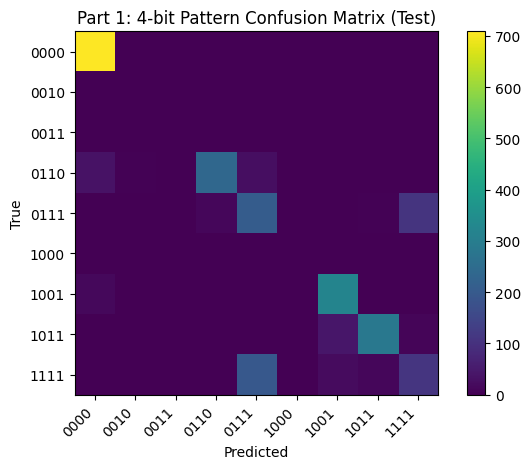

[[709   0   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 35   4   0 237  25   0   0   0   0]
 [  0   2   0  12 205   0   0   3 107]
 [  0   0   0   0   0   0   0   0   0]
 [ 16   0   0   0   0   2 320   1   0]
 [  0   1   2   0   0   0  43 284  10]
 [  0   0   0   1 196   0  21  13 109]]


In [8]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [9]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [10]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        return self.net(x)


In [11]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model2 = DNN_MultiLabel4()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)


In [12]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # TODO: zero gradients
            optimizer.zero_grad()

            # TODO: logits = model(xb)
            logits = model(xb)

            # TODO: loss = loss_fn(logits, yb)
            loss=loss_fn(logits, yb)

            # TODO: backward + step
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch: ", epochs, " | Avg train loss: ", avg_loss)

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

model = model.to(device)
train_part2(model, train_loader_2, epochs=EPOCHS)


Epoch:  1000  | Avg train loss:  0.5720832410919497
Epoch:  1000  | Avg train loss:  0.22204873385060184
Epoch:  1000  | Avg train loss:  0.21317355844464053


In [13]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.9305    0.7383    0.8234      2377
           C     1.0000    0.9289    0.9631      2263
           B     0.9982    0.9287    0.9622      3057
           A     0.9815    0.9962    0.9888      3144

   micro avg     0.9805    0.9066    0.9421     10841
   macro avg     0.9776    0.8980    0.9344     10841
weighted avg     0.9789    0.9066    0.9397     10841
 samples avg     0.6820    0.6461    0.6596     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2994  131]
 [ 622 1755]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3239    0]
 [ 161 2102]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2440    5]
 [ 218 2839]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2299   59]
 [  12 3132]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.9384    0.7331    0.8231      1019
           C     1.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

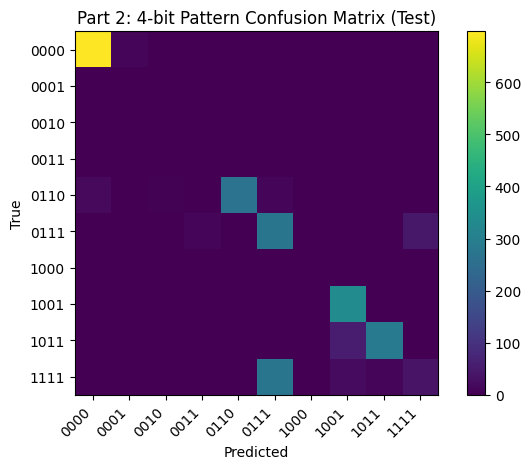

[[698  10   0   0   0   0   0   2   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [ 19   0   4   0 265  13   0   0   0   0]
 [  0   0   0  11   0 271   0   0   1  46]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   1 338   0   0]
 [  0   0   0   0   0   0   0  52 288   0]
 [  0   0   0   0   0 272   0  21   9  38]]


In [14]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [15]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [16]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [17]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiClass6()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)


In [18]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # TODO: zero gradients
            optimizer.zero_grad()

            # TODO: logits = model(xb)
            logits = model(xb)

            # TODO: loss = loss_fn(logits, yb)
            loss = loss_fn(logits, yb)

            # TODO: backward + step
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch: ", epochs, " | Avg train loss: ", avg_loss)


@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

model = model.to(device)
train_part3(model, train_loader_3, epochs=EPOCHS)



Epoch:  1000  | Avg train loss:  1.8640597561670191
Epoch:  1000  | Avg train loss:  0.6565209671134561
Epoch:  1000  | Avg train loss:  0.643650189892503



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9661    1.0000    0.9828      1655
          LG     0.9084    0.9544    0.9309       790
          LL     0.9823    0.8677    0.9215       703
         LLG     0.9147    0.9458    0.9300       794
         LLL     0.5285    0.5919    0.5584       767
        LLLG     0.4650    0.3859    0.4218       793

    accuracy                         0.8233      5502
   macro avg     0.7942    0.7910    0.7909      5502
weighted avg     0.8193    0.8233    0.8199      5502



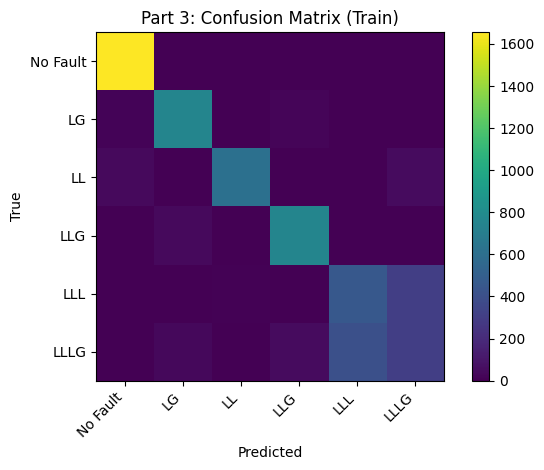


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9634    1.0000    0.9813       710
          LG     0.9255    0.9528    0.9390       339
          LL     0.9962    0.8638    0.9253       301
         LLG     0.9183    0.9588    0.9381       340
         LLL     0.5265    0.5745    0.5494       329
        LLLG     0.4631    0.4059    0.4326       340

    accuracy                         0.8249      2359
   macro avg     0.7988    0.7926    0.7943      2359
weighted avg     0.8226    0.8249    0.8225      2359



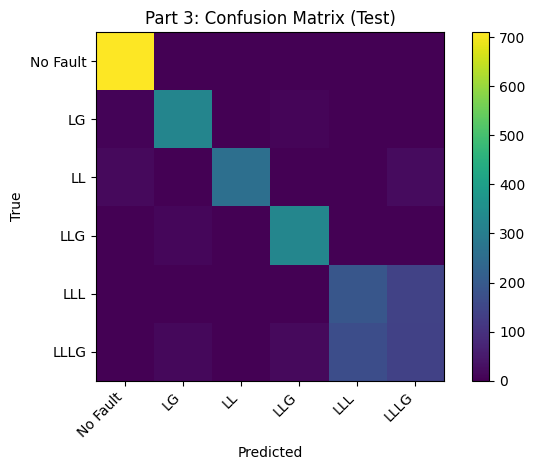

In [19]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1: *Multi-class fits this dataset best because it has the highest test f-1 score for the macro avg at around 0.8. The regression-style and multi-label both have lower sample-averaged f-1 scores at around 0.65.*
- Q2: *Yes, invalid fault patterns were observed in both part 1 and part 2. In part 1, many entire rows are zero. This suggests that some true classes were never predicted correctly at all. In part 2, there were mass leakage into specific columns, which suggests the model is mixing bits instead of producing valid codes and that bit outputs decoded to the wrong class frequently. Essentially, these behaviours suggests that the bit representation from the model predictions does not know which combinations are valid and produces out-of-code predictions.*
- Q3: *For parts 1 and 2, bit G is the hardest to predict as demonstrated by their lower f-1 score when compared to other bits. For part 3, the LLL and LLLG are the hardest, as indicated by their low f-1 score and by looking at the confusion matrix, where there's heavy confusion between them. These have much weaker diagonal compared to the other classes. One plausible reason is that their electrical signatures are highly similar, which gives model much difficulty in distinguishing between them.*


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [27]:
# ---- 1) Build binary labels from the existing 4-bit labels (Y_bits)
# Y_bits is (N,4) with columns [G,C,B,A]
y_bin = (np.any(Y_bits != 0, axis=1)).astype(int)  # 0=no fault, 1=fault

# ---- 2) 70/30 stratified split
X_train_5, X_test_5, y_train_5, y_test_5 = train_test_split(
    X, y_bin,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_bin
)

print("Binary class counts (train):", np.bincount(y_train_5))
print("Binary class counts (test): ", np.bincount(y_test_5))

# ---- 3) RobustScaler (fit on train only)
scaler_5 = RobustScaler()
X_train_s5 = scaler_5.fit_transform(X_train_5).astype(np.float32)
X_test_s5  = scaler_5.transform(X_test_5).astype(np.float32)

# ---- 4) Torch datasets / loaders
Xtr5 = torch.from_numpy(X_train_s5)
Xte5 = torch.from_numpy(X_test_s5)

# BCEWithLogitsLoss expects float targets, shape (N,1)
ytr5 = torch.from_numpy(y_train_5.astype(np.float32)).view(-1, 1)
yte5 = torch.from_numpy(y_test_5.astype(np.float32)).view(-1, 1)

train_loader_5 = DataLoader(TensorDataset(Xtr5, ytr5), batch_size=BATCH_SIZE, shuffle=True)
test_loader_5  = DataLoader(TensorDataset(Xte5, yte5), batch_size=BATCH_SIZE, shuffle=False)

Binary class counts (train): [1655 3847]
Binary class counts (test):  [ 710 1649]


In [28]:
class DNN_BinaryFault(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h2, 1)   # single logit
        )

    def forward(self, x):
        return self.net(x)

In [30]:
model = DNN_BinaryFault().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)

def train_binary(model, loader, epochs=EPOCHS):
    model.train()
    n = len(loader.dataset)

    for ep in range(1, epochs + 1):
        total_loss = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)

        if ep in [1, epochs // 2, epochs]:
            print(f"Epoch {ep:4d}/{epochs} | avg train loss = {total_loss / n:.6f}")

@torch.no_grad()
def predict_binary(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)
    preds = (probs >= threshold).astype(int)
    return preds, probs

# Train
train_binary(model, train_loader_5, epochs=EPOCHS)

Epoch    1/1000 | avg train loss = 0.611894
Epoch  500/1000 | avg train loss = 0.056519
Epoch 1000/1000 | avg train loss = 0.046922


In [33]:
def evaluate_split(name, X_split, y_split):
    preds, probs = predict_binary(model, X_split, threshold=0.5)

    print(f"\n=== {name} ===")
    print(classification_report(y_split, preds, target_names=["No Fault", "Fault"], digits=4))

    cm = confusion_matrix(y_split, preds)
    print("Confusion matrix:")
    print(cm)
    return cm

cm_train = evaluate_split("TRAIN", X_train_s5, y_train_5)
cm_test  = evaluate_split("TEST",  X_test_s5,  y_test_5)


=== TRAIN ===
              precision    recall  f1-score   support

    No Fault     0.9600    0.9994    0.9793      1655
       Fault     0.9997    0.9821    0.9908      3847

    accuracy                         0.9873      5502
   macro avg     0.9798    0.9907    0.9850      5502
weighted avg     0.9878    0.9873    0.9873      5502

Confusion matrix:
[[1654    1]
 [  69 3778]]

=== TEST ===
              precision    recall  f1-score   support

    No Fault     0.9660    1.0000    0.9827       710
       Fault     1.0000    0.9848    0.9924      1649

    accuracy                         0.9894      2359
   macro avg     0.9830    0.9924    0.9875      2359
weighted avg     0.9898    0.9894    0.9895      2359

Confusion matrix:
[[ 710    0]
 [  25 1624]]
